In [2]:
# https://gymnasium.farama.org/
import gymnasium as gym
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
gym.envs.registry.items()

dict_items([('CartPole-v0', EnvSpec(id='CartPole-v0', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=195.0, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=0, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')), ('CartPole-v1', EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')), ('MountainCar-v0', EnvSpec(id='MountainCar-v0', entry_point='gymnasium.envs.classic_control.mountain_car:MountainCarEnv', reward_threshold=-110.0, nondeterministic=False, max_episode_steps=200, order_enforce=True

In [4]:
env = gym.make("LunarLander-v3", render_mode="human")
obs, info = env.reset(seed=42)

for _ in range(1000):

    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    obs, reward, terminated, truncated, info = env.step(action)

    # optional: slow it a bit so you can see what's happening
    time.sleep(1/60)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        obs, info = env.reset()

env.close()

C:\Users\username\Projects\MachineLearning\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [5]:
env = gym.make('CartPole-v1') # create the environment
obs = env.reset(seed=42) # reset the environment to get the initial
obs # the observation is a 1D array of 4 numbers: [cart position, cart velocity, pole angle, pole angular velocity]

(array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32),
 {})

In [6]:
env = gym.make('CartPole-v1', render_mode='rgb_array') # create the environment
obs, info = env.reset(seed=42) # reset the environment to get the initial observation and info

img = env.render() # render the environment and get the image as a numpy array
img.shape # the image is 400 pixels wide, 600 pixels high and has 3

(400, 600, 3)

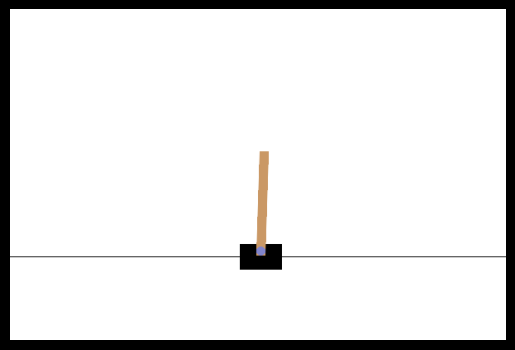

In [7]:
plt.imshow(img) # display the image
plt.axis('off') # hide the axes
plt.show() # show the plot

In [8]:
env.action_space # the action space is discrete with 2 possible actions: 0 (push cart to the left) and 1 (push cart to the right)

Discrete(2)

In [9]:
action = 1 # choose an action (in this case, we choose to push the cart to the right)
obs, reward, terminated, truncated, info = env.step(action) # take the action and observe the result
print(f'Obesrvation: {obs}, Reward: {reward}, Terminated: {terminated}, Truncated: {truncated}')

Obesrvation: [ 0.02727336  0.18847767  0.03625453 -0.26141977], Reward: 1.0, Terminated: False, Truncated: False


In [10]:
caty_position, cart_velocity, pole_angle, pole_angular_velocity = obs
print(f'Cart Position: {caty_position}, Cart Velocity: {cart_velocity}, Pole Angle: {pole_angle}, Pole Angular Velocity: {pole_angular_velocity}')

Cart Position: 0.02727336250245571, Cart Velocity: 0.18847766518592834, Pole Angle: 0.036254528909921646, Pole Angular Velocity: -0.26141977310180664


In [11]:
obs # obs[0] is the cart position, obs[1] is the cart velocity, obs[2] is the pole angle and obs[3] is the pole angular velocity
reward # the reward is 1 for every step taken, including the termination step, where the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center
terminated # the episode is terminated if the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center, or if the episode length is greater than 500 steps
truncated # the episode is truncated if the episode length is greater than 500 steps

False

In [13]:
def basic_policy(obs):
    _, _, pole_angle, _ = obs
    return 0 if pole_angle < 0 else 1

env = gym.make("CartPole-v1", render_mode="rgb_array")

totals = []
for episode in range(200):
    obs, info = env.reset()  # don't reseed every episode
    terminated = truncated = False
    episode_rewards = 0
    step = 0

    while not (terminated or truncated):
        action = basic_policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_rewards += reward
        step += 1

    totals.append(episode_rewards)

env.close()

print("mean/std/min/max:", np.mean(totals), np.std(totals), np.min(totals), np.max(totals))

mean/std/min/max: 40.735 8.55656327037906 25.0 60.0
